##### Imports & setup

In [1]:
import pandas as pd
from magcvs_library.functions import corner_plot, modified_corner_plot
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

# Feature names (without linear features):
feature_names = ['mean', 'weightedMean', 'std', 'median', 'amplitude', 'beyond1Std', 'cusum', 'IPR10',
                 'kurtosis', 'MPR40_5', 'MPR20_10', 'maxSlope', 'medianAbsDev', 'medianBRP10',
                 'percentAmplitude', 'meanVariance', 'andersonDarlingNorm', 'chi2', 'skew', 'stetsonK']

---
## Getting data

In [2]:
# The following paths should be changed accordingly. The data can be saved in a csv from the clean_data.ipynb notebook.
positive_g = pd.read_csv('../../data/clean_data/positive_class_g.csv', index_col=0)
positive_r = pd.read_csv('../../data/clean_data/positive_class_r.csv', index_col=0)
negative_g = pd.read_csv('../../data/clean_data/negative_class_g.csv', index_col=0)
negative_r = pd.read_csv('../../data/clean_data/negative_class_r.csv', index_col=0)

lc_positive_g = pd.read_parquet('../../data/one_year_data/lc_positive_g.parquet')
lc_positive_r = pd.read_parquet('../../data/one_year_data/lc_positive_r.parquet')
lc_negative_g = pd.read_parquet('../../data/one_year_data/lc_negative_g.parquet')
lc_negative_r = pd.read_parquet('../../data/one_year_data/lc_negative_r.parquet')

---
## Corner plots

### Plot for the positive class - g and r filters

In [ ]:
corner_plot(positive_g[feature_names], positive_r[feature_names], ['g filter', 'r filter'])

### Plot for both classes - g filter

In [ ]:
corner_plot(positive_g[feature_names], negative_g[feature_names], data_labels=['magCVs', 'other']) # Should take less than a minute to run

### Plot for both classes - r filter

In [ ]:
corner_plot(positive_r[feature_names], negative_r[feature_names], data_labels=['magCVs', 'other']) # Should take less than a minute to run

### g versus r plot - both classes

In [ ]:
# Grouping the matching lines in g and r filter to have the same dimension for the modified corner plot:

index_positive_g = set(positive_g.index)
index_positive_r = set(positive_r.index)
index_negative_g = set(negative_g.index)
index_negative_r = set(negative_r.index)

positive_intersection = list(index_positive_g.intersection(index_positive_r))
negative_intersection = list(index_negative_g.intersection(index_negative_r))

positive_g2 = positive_g.loc[positive_intersection]
positive_r2 = positive_r.loc[positive_intersection]
negative_g2 = negative_g.loc[negative_intersection]
negative_r2 = negative_r.loc[negative_intersection]

In [ ]:
modified_corner_plot(positive_g2[feature_names], positive_r2[feature_names], negative_g2[feature_names], negative_r2[feature_names], ['g filter', 'r filter'])

## Bar plots for the cds cross match classes

In [ ]:
# Extracting the classes and their counts:
classes_g, counts_g = np.unique(negative_g['cdsxmatch'], return_counts=True)
classes_r, counts_r = np.unique(negative_r['cdsxmatch'], return_counts=True)
classes_g_dict = dict(zip(classes_g, counts_g))
classes_r_dict = dict(zip(classes_r, counts_r))

# removing the unknown class so that it does not crunch the scale of the plot:
nb_unknown_g = classes_g_dict.pop('Unknown')
nb_unknown_r = classes_r_dict.pop('Unknown')
print(f'Number of unknown objects in the g filter: {nb_unknown_g}\nNumber of unknown objects in the r filter: {nb_unknown_r}')

#### g filter

In [ ]:
plt.figure(figsize=(8, 20))
sns.barplot(classes_g_dict, orient='h');

#### r filter

In [ ]:
plt.figure(figsize=(8, 20))
sns.barplot(classes_r_dict, orient='h');

## Periodograms

In [3]:
lc_positive_g

,objectId,time_range (yr),nb_of_points,jd,magpsf,sigmapsf
0,ZTF18aajbbtc,1.2,26,"[2458964.8603009, 2458970.9473958, 2458981.798...","[19.937504, 20.17651, 19.68468, 19.866104, 20....","[0.13127863, 0.19047813, 0.14948329999999999, ..."
1,ZTF17aabtjog,5.4,373,"[2458791.0369676, 2458794.0294213, 2458796.782...","[17.909153, 18.073462, 17.929792, 18.961445, 1...","[0.08615332, 0.076107696, 0.13604744, 0.164108..."
2,ZTF18aabktwo,5.4,361,"[2458790.0164236, 2458790.0173264, 2458803.054...","[18.281866, 18.33712, 18.243118, 18.319246, 18...","[0.07627481, 0.06954320500000001, 0.06830946, ..."
3,ZTF17aaaadkj,5.2,99,"[2458831.7310417, 2458836.7272222, 2458867.693...","[16.837646, 19.403118, 20.062859, 19.604828, 1...","[0.036172897, 0.10327293, 0.20844895, 0.130478..."
4,ZTF18aditqga,2.7,18,"[2459751.8432292, 2459762.8315509, 2459842.644...","[20.150043, 19.973494, 19.76471, 19.7964169999...","[0.20714514, 0.20415534, 0.20913929, 0.1516088..."
...,...,...,...,...,...,...
73,ZTF18admoxby,2.5,31,"[2459770.9170718, 2459787.9521296, 2459790.865...","[16.949766, 16.665680000000002, 16.551079, 16....","[0.06754233, 0.09393745, 0.061662827, 0.072750..."
74,ZTF17aaaitci,5.3,113,"[2458791.0304514, 2458796.7906944, 2458846.750...","[17.957117, 17.643747, 19.20626, 18.835001, 18...","[0.04052226, 0.06781802, 0.08295316, 0.0993870..."
75,ZTF18aaylcic,5.2,275,"[2458853.0271296, 2458856.003044, 2458883.9837...","[17.849487, 17.895292, 18.005047, 17.87651, 17...","[0.0685368, 0.06260510500000001, 0.06754954, 0..."
76,ZTF18abadecm,4.1,13,"[2459025.8229514, 2459305.9935069, 2459308.003...","[20.39963, 16.675056, 18.883911, 19.918055, 19...","[0.19219604, 0.028309064000000002, 0.06790615,..."


In [4]:
lc_negative_g

,objectId,time_range (yr),nb_of_points,jd,magpsf,sigmapsf
0,ZTF18acvqiot,5.2,48,"[2458820.7358912, 2458836.9090394, 2458846.748...","[16.82549, 16.81379, 16.748367000000002, 16.58...","[0.07162208, 0.08929887, 0.063677706, 0.061110..."
1,ZTF18acpdrdt,5.3,107,"[2458796.7574421, 2458802.7302546, 2458820.711...","[16.477589, 16.677395, 16.249882, 16.008753, 1...","[0.06837262, 0.049022004, 0.082877725, 0.05750..."
2,ZTF22abtsipc,2.1,4,"[2459913.8385185, 2460251.8673495, 2460637.777...","[19.42485, 19.003923, 19.019928, 18.759989]","[0.15123709, 0.1478552, 0.12251697500000001, 0..."
3,ZTF18aachppe,4.5,23,"[2458981.6622106, 2459176.9939699, 2459203.872...","[19.898981, 20.135723, 20.219852, 20.177742, 1...","[0.17462784, 0.17414254, 0.2133387, 0.17139581..."
4,ZTF18abqrjvo,4.3,69,"[2458790.7905093, 2458877.6856944, 2459038.982...","[19.161182, 19.291912, 19.018986, 18.921316, 1...","[0.17309387, 0.20647369999999998, 0.21063133, ..."
...,...,...,...,...,...,...
358,ZTF20aaehjvk,4.2,12,"[2459199.0126157, 2459350.696412, 2460250.0146...","[18.842196, 18.646515, 17.90122, 18.239763, 18...","[0.20352833, 0.12779798, 0.12048773500000001, ..."
359,ZTF22ablbkpu,1.3,12,"[2460235.9927315, 2460291.9375116, 2460340.776...","[20.108961, 20.281279, 20.363243, 20.25547, 20...","[0.20200245, 0.21417896, 0.21516764, 0.1951024..."
360,ZTF20aaoymex,3.9,7,"[2458903.8265394, 2458936.7777199, 2458954.804...","[20.556223, 20.528559, 20.3491, 20.328209, 20....","[0.20738544, 0.18487456, 0.21610269000000001, ..."
361,ZTF18abwbnno,5.1,28,"[2458846.7395602, 2458903.7369444, 2459137.927...","[20.049372, 19.828333, 20.12341, 19.899672, 20...","[0.17890119999999998, 0.13486966, 0.19100043, ..."


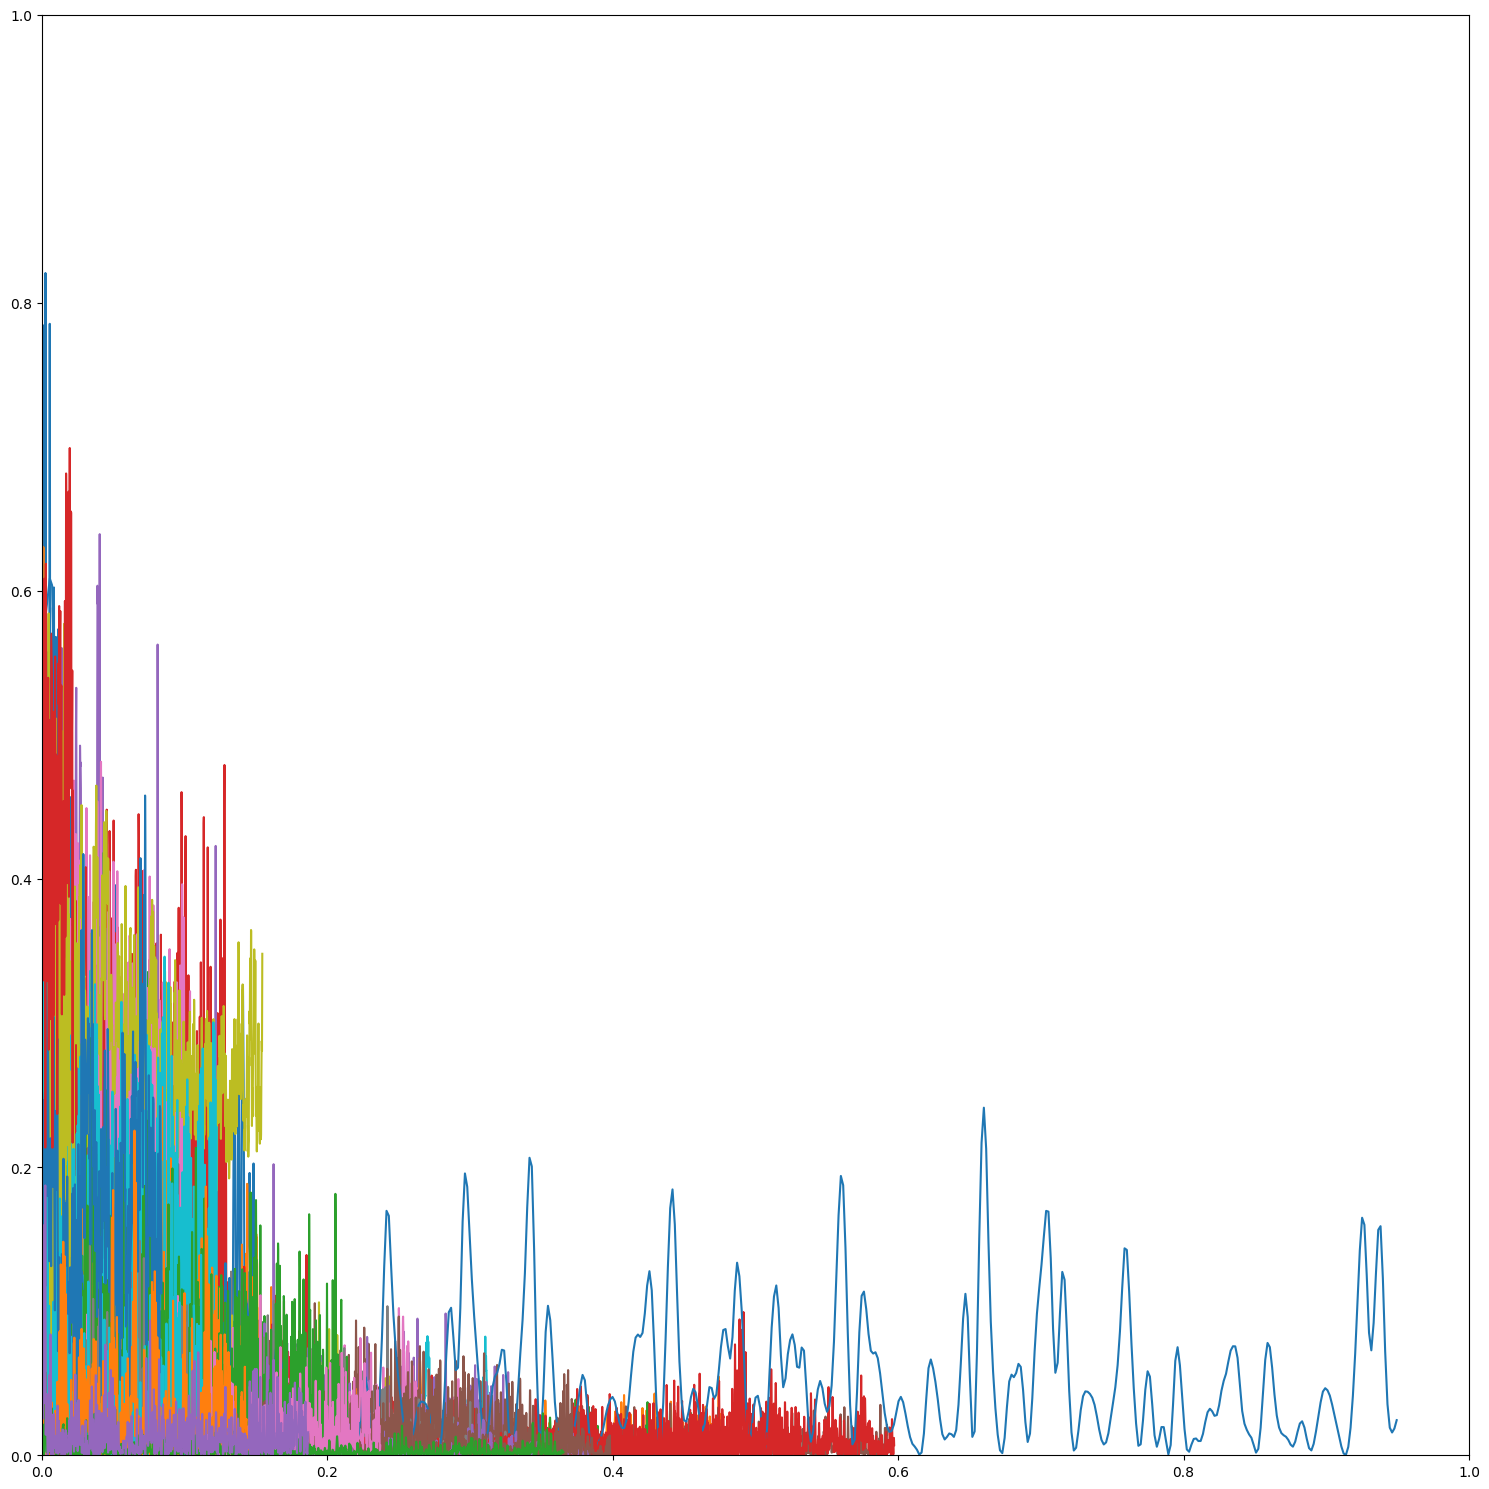

In [5]:
plt.figure(figsize=(15, 15))
for i in range(len(lc_positive_g)):
    t = lc_positive_g['jd'][i]
    m = lc_positive_g['magpsf'][i]
    m_err = lc_positive_g['sigmapsf'][i]
    frequency, power = LombScargle(t, m, m_err).autopower()
    if len(t) >= 10:
        plt.plot(frequency, power)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()

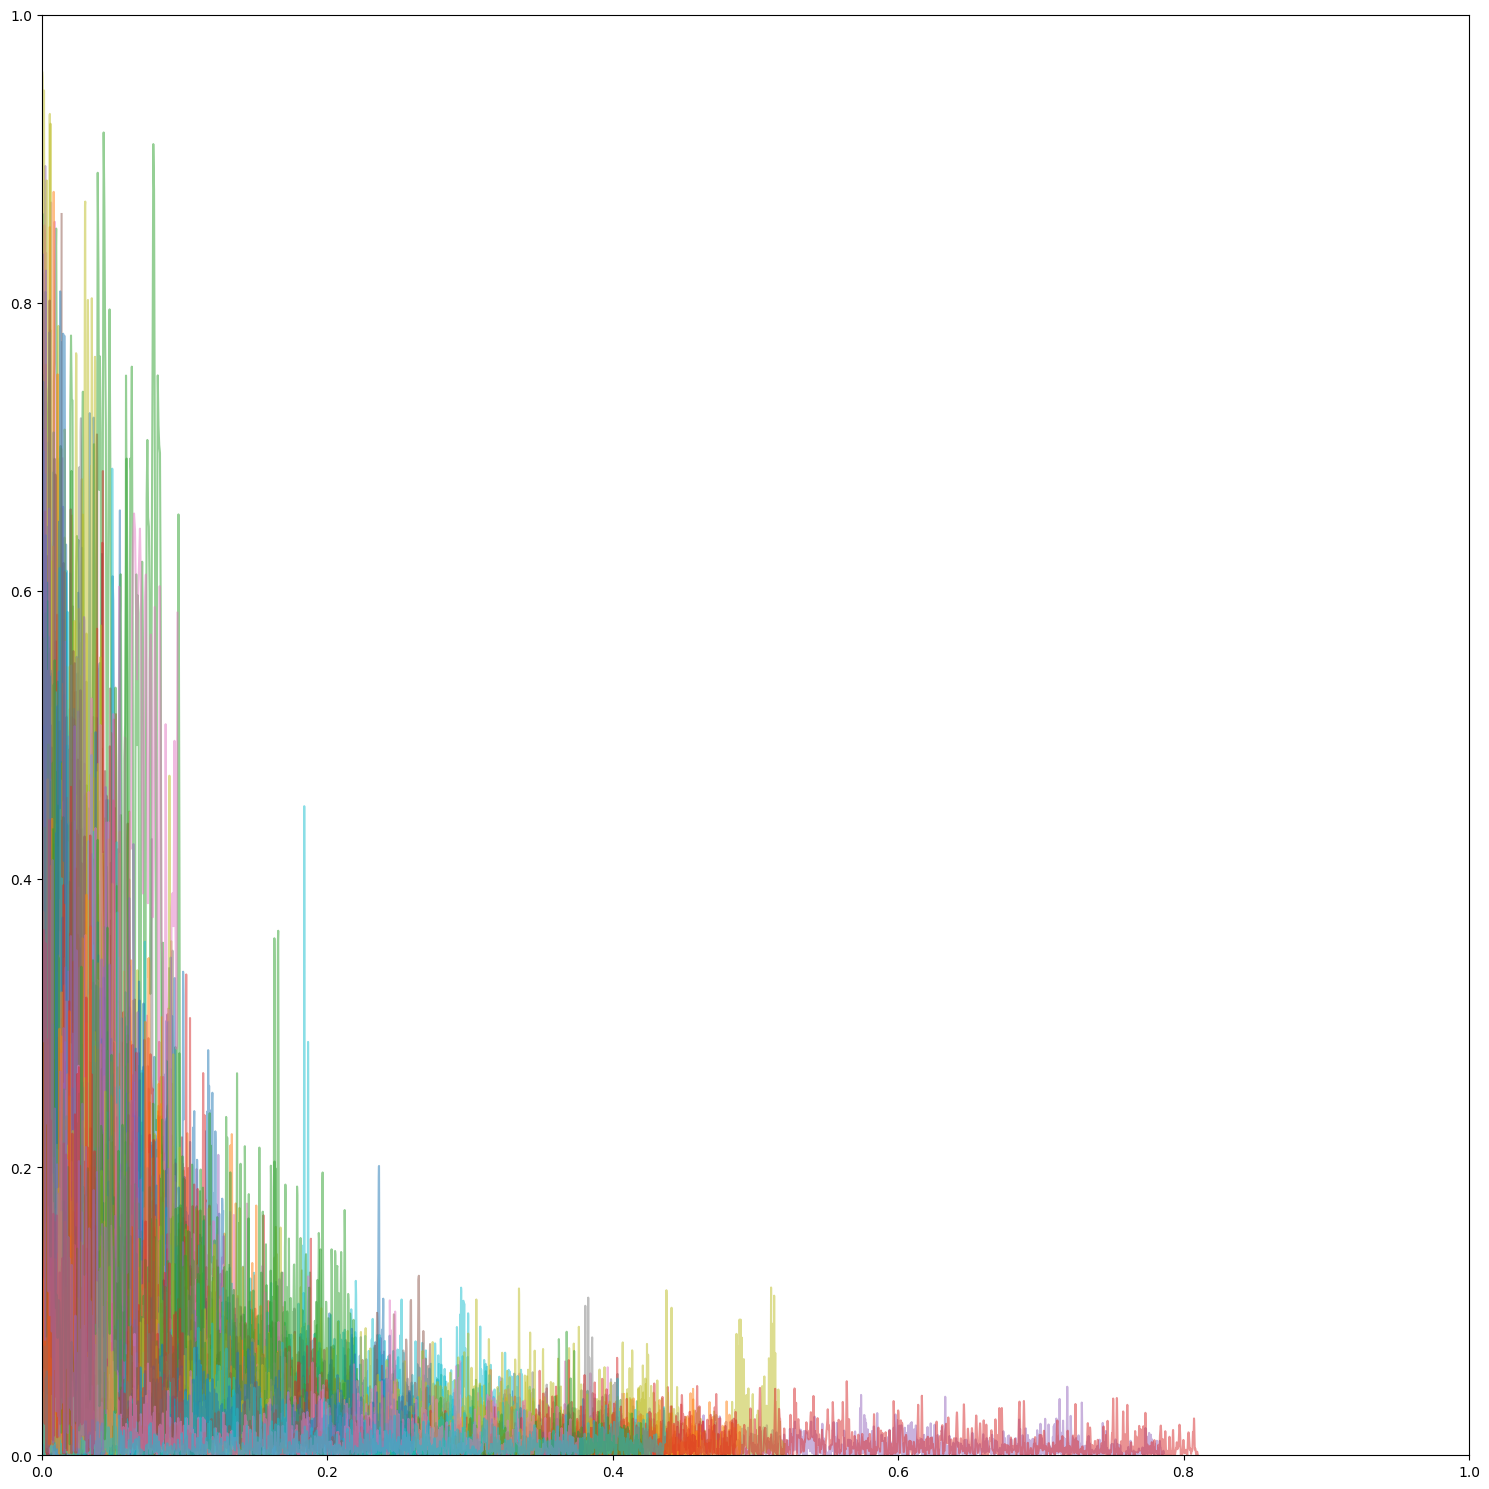

In [6]:
plt.figure(figsize=(15, 15))
for i in range(len(lc_negative_g)):
    t = lc_negative_g['jd'][i]
    m = lc_negative_g['magpsf'][i]
    m_err = lc_negative_g['sigmapsf'][i]
    frequency, power = LombScargle(t, m, m_err).autopower()
    if len(t) >= 10:
        plt.plot(frequency, power, alpha=.5)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()

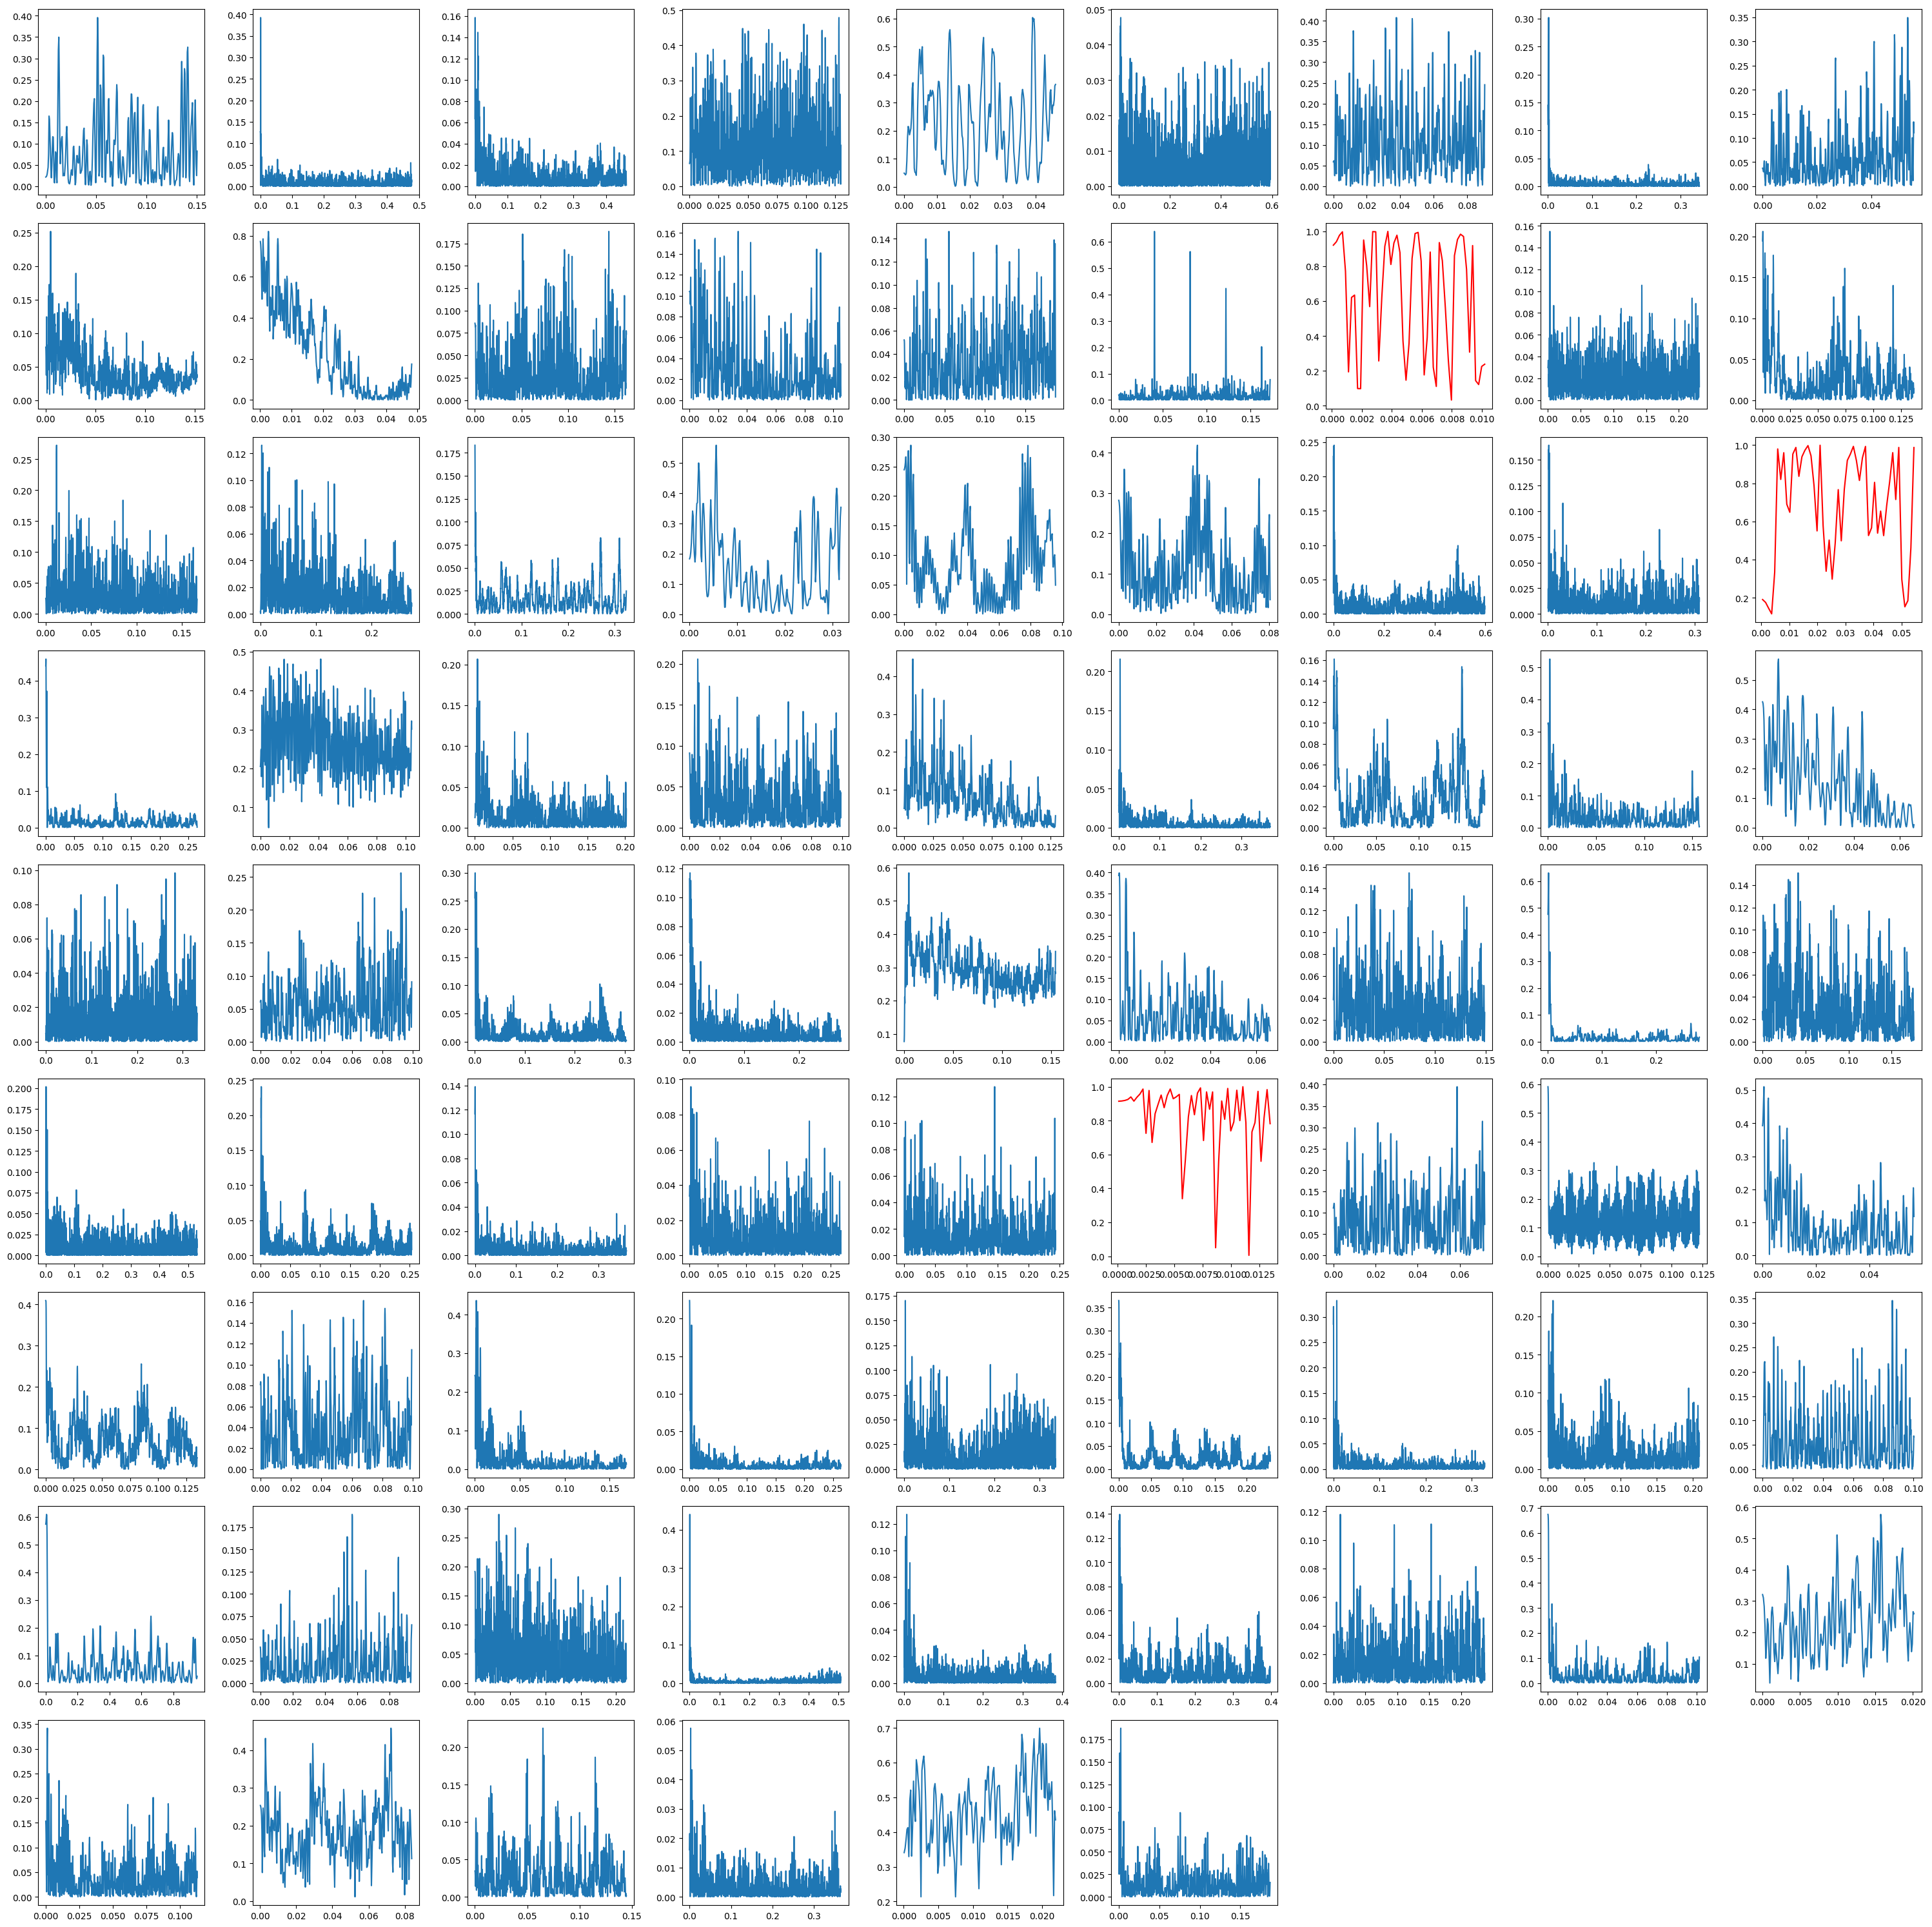

In [11]:
plt.figure(figsize=(30, 30))
for i in range(len(lc_positive_g)):
    dim = int(np.ceil(np.sqrt(len(lc_positive_g))))
    plt.subplot(dim, dim, i+1)
    t = lc_positive_g['jd'][i]
    m = lc_positive_g['magpsf'][i]
    m_err = lc_positive_g['sigmapsf'][i]
    frequency, power = LombScargle(t, m, m_err).autopower()
    if len(t) >= 10:
        plt.plot(frequency, power)
    else:
        plt.plot(frequency, power, c='r')

plt.tight_layout()

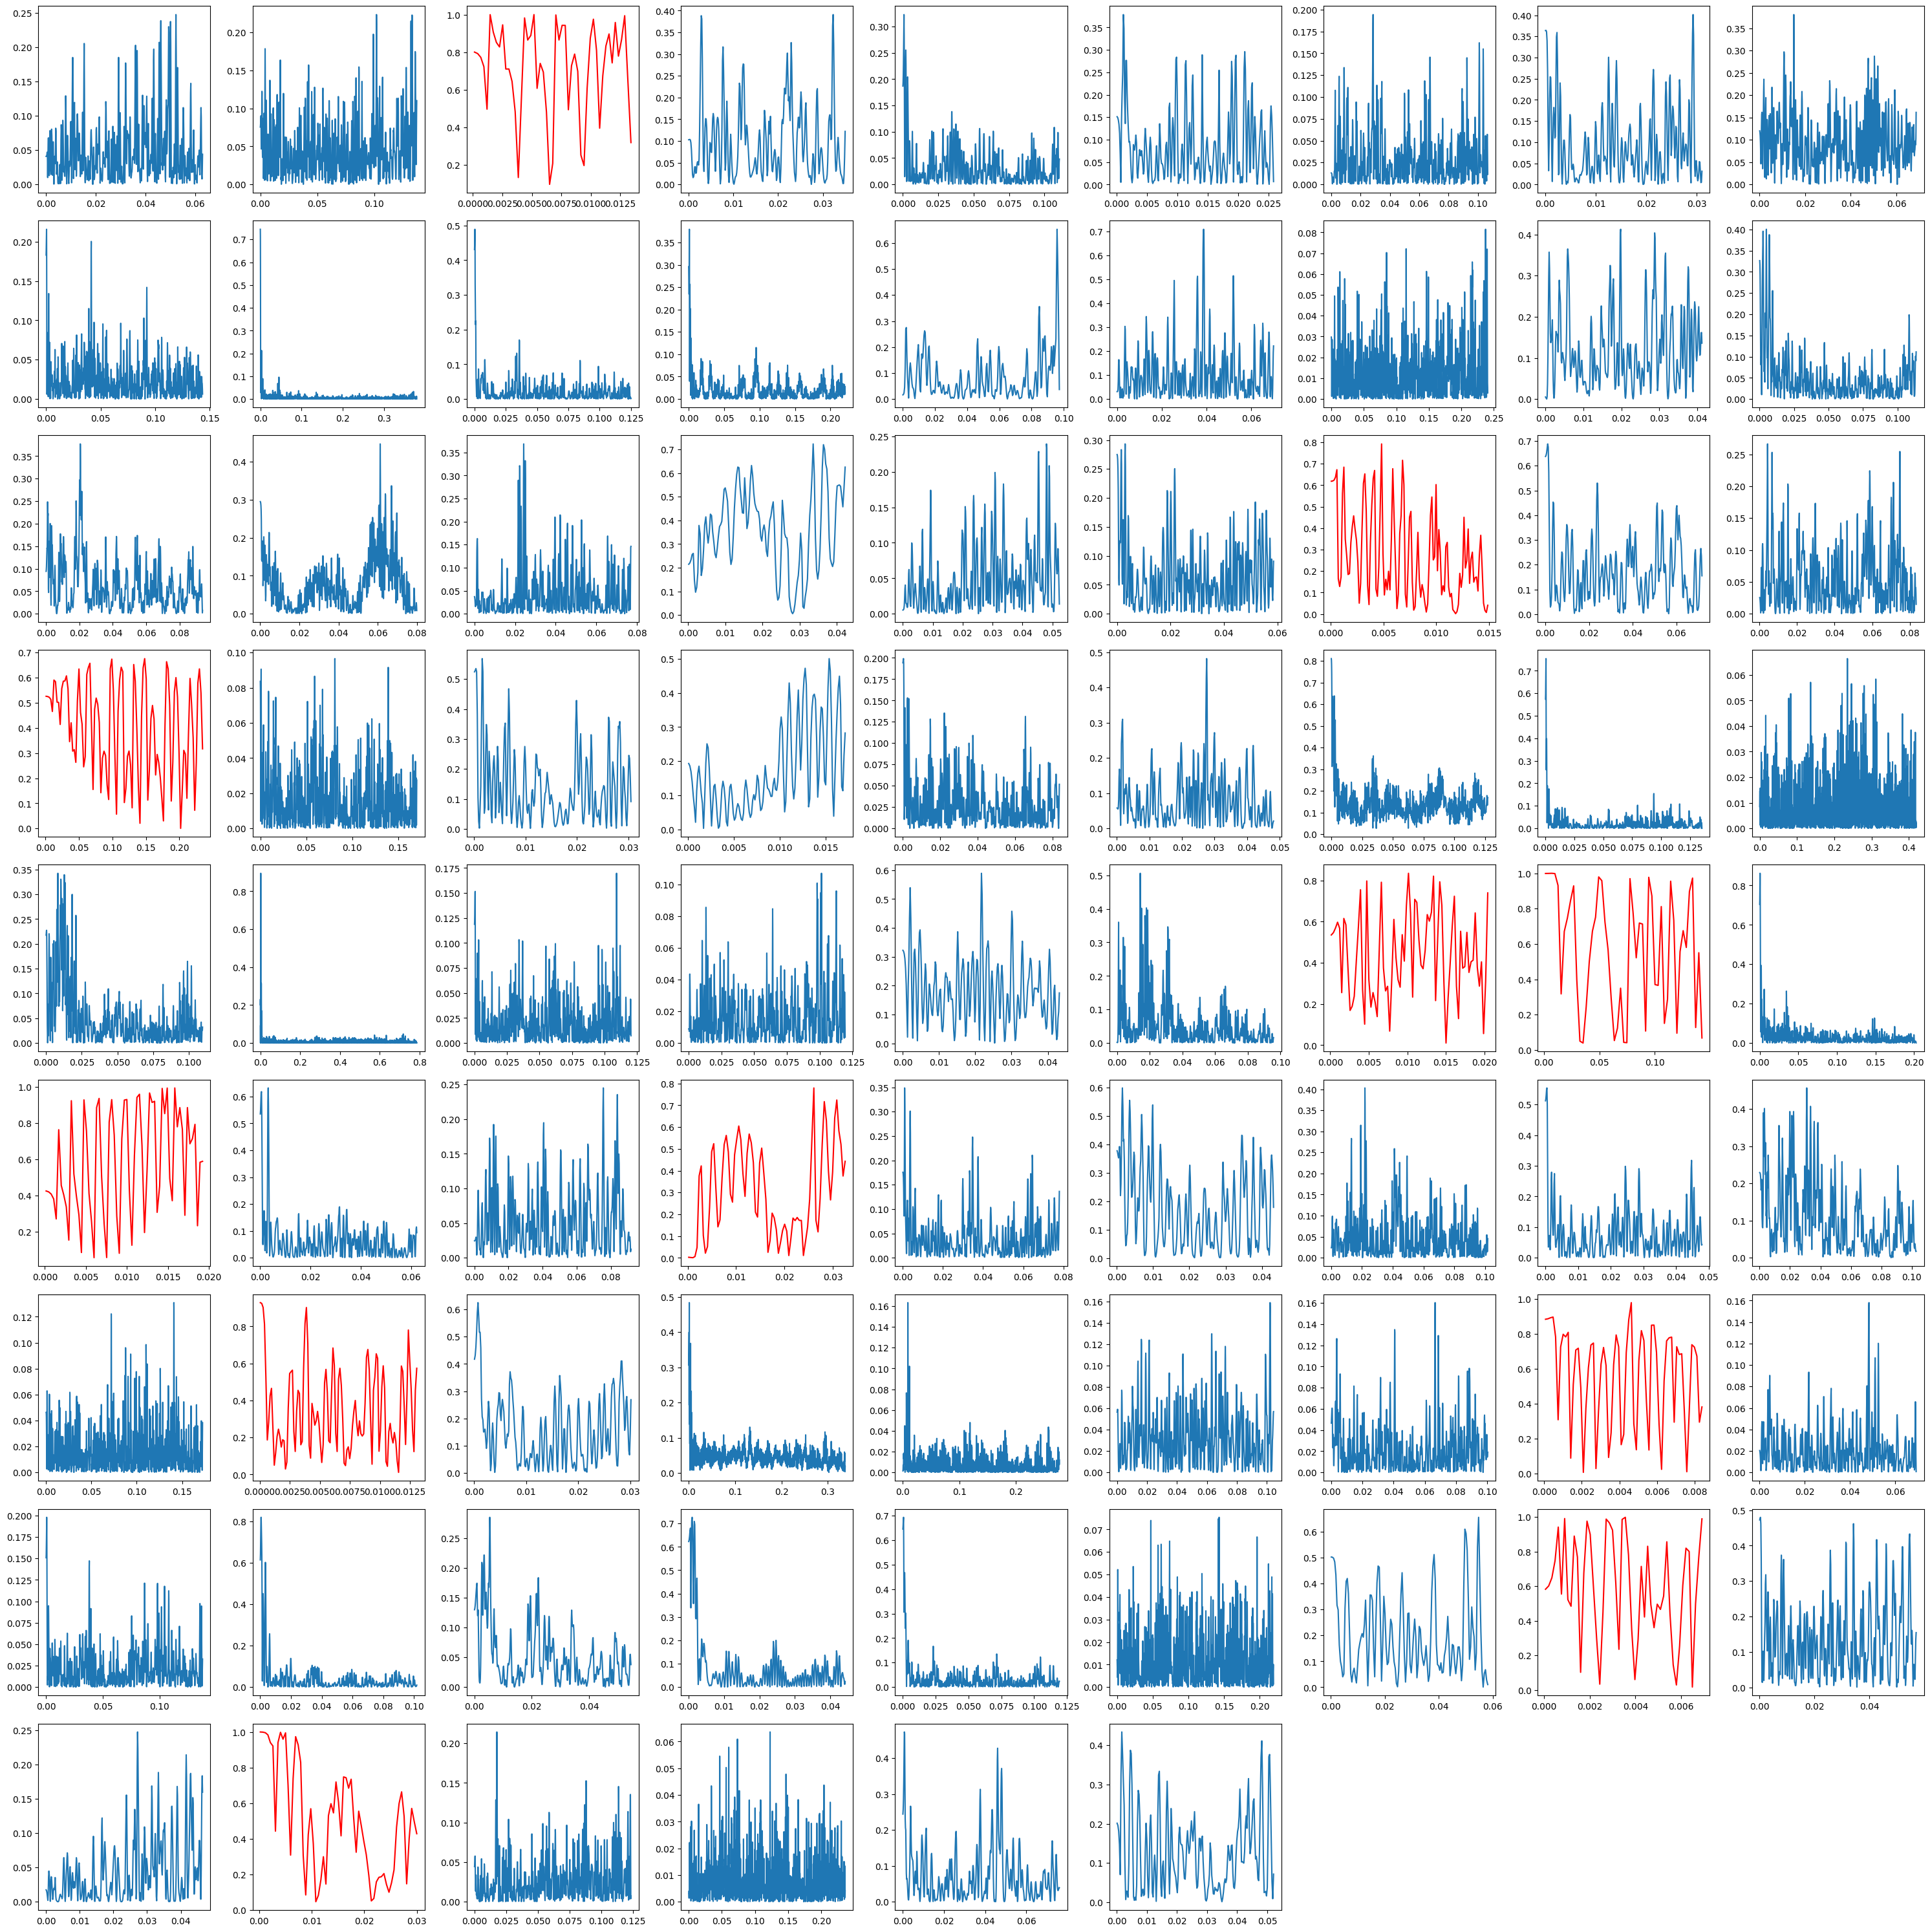

In [12]:
plt.figure(figsize=(30, 30))
for i in range(len(lc_positive_g)):
    dim = int(np.ceil(np.sqrt(len(lc_positive_g))))
    plt.subplot(dim, dim, i+1)
    t = lc_negative_g['jd'][i]
    m = lc_negative_g['magpsf'][i]
    m_err = lc_negative_g['sigmapsf'][i]
    frequency, power = LombScargle(t, m, m_err).autopower()
    if len(t) >= 10:
        plt.plot(frequency, power)
    else:
        plt.plot(frequency, power, c='r')

plt.tight_layout()